# MMM com Meridian: quanto cada campanha de mídia realmente entrega?

Projeto de **Marketing Mix Modeling (MMM)** em cenário de fintech, com dados sintéticos onde **a verdade é conhecida**. Isso permite algo que quase nunca dá pra fazer com dado real: conferir no final se o modelo recuperou o que foi plantado.

É a reconstrução pública de um projeto real que fiz no varejo, usando a biblioteca **Meridian** (Google) no Colab, que era onde estava a versão mais atualizada.

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GabiGattiRodrigues/prisma/blob/main/mmm_meridian.ipynb) · [Documentação do Meridian](https://developers.google.com/meridian) · [Glossário](https://developers.google.com/meridian/docs/basics/glossary)

*O botão abre uma cópia do notebook direto do GitHub: você pode rodar e editar a sua cópia, mas o original não é alterado.*

## O que muda em relação a um MMM "de livro"

1. **A métrica de resposta nem sempre é dinheiro.** No projeto original o alvo era *vidas trazidas para um programa de saúde*, não receita. Aqui eu rodo **dois modelos**: um para **novas contas abertas** (KPI de volume, sem valor monetário) e outro para **receita** (KPI monetário). Os dois rankings de canais não são iguais, e isso é parte da conclusão.
2. **Promoções acontecem em dias diferentes da semana.** Uma semana pode ter promoção na segunda, outra na quarta e na sexta. O dado que entra no modelo é o **desconto médio diário da semana** (dias sem promo contam zero).
3. **Fatores econômicos e calendário** entram como controle: desemprego, IPCA e feriados nacionais.
4. **Curvas de resposta têm que fazer sentido de negócio.** Só ter MAPE baixo não basta, e o problema principal do projeto original foi exatamente esse: modelo bem ajustado, contribuição estranha.

## Roteiro

| # | Seção | Pergunta que responde |
|---|---|---|
| 1 | Setup e dados | O que temos? |
| 2 | Análise exploratória | Onde mora o risco (multicolinearidade, promoções)? |
| 3 | Adstock e saturação | O que o modelo está estimando, na prática? |
| 4 | Modelo ingênuo | O que acontece com o "default"? (o problema do MAPE bom com contribuição ruim) |
| 5 | Modelo ajustado: novas contas | O que muda com decisões de modelagem? E o que há dentro do baseline (controles)? |
| 6 | Modelo ajustado: receita | Mesmo método, KPI monetário |
| 7 | Verdade vs. estimado | O modelo recuperou o que plantamos? |
| 8 | Quando investir | Bomba ou diluído? Tudo em 1 mês ou espalhado no ano? |
| 9 | Conclusões e limitações | O que eu confiaria e o que não |

## 1. Setup e dados

### 1.1 Instalação
No Colab rode a célula abaixo. O Meridian usa JAX/TensorFlow Probability por baixo. **Dica:** em `Ambiente de execução > Alterar tipo de ambiente de execução` escolha GPU, a amostragem (MCMC) fica bem mais rápida. Em CPU também funciona, só demora mais.

In [1]:
# Instala o Meridian só se ainda não estiver instalado (no Colab normalmente não está).
try:
    import meridian
except ImportError:
    !pip install -q google-meridian
    import meridian

print("Meridian versão:", meridian.__version__)

Meridian versão: 2.0.0


In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Meridian: carga de dados, especificação do modelo, priors e análise dos resultados
from meridian.data import load
from meridian.model import model, spec, prior_distribution
from meridian.analysis import analyzer, visualizer, tensors
import jax.numpy as jnp    # usado na seção de cronogramas (tensores de mídia hipotética)

# Os avisos (UserWarning) do Meridian são informativos e repetitivos; escondo para o notebook ficar limpo.
warnings.filterwarnings("ignore")

# Estilo dos gráficos (paleta em azul, com laranja para destacar o que é "real"/"verdade")
AZUL, AZUL_CLARO, CINZA, LARANJA = "#1f5fbf", "#9dbdec", "#6b7280", "#e07b39"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25, "axes.titleweight": "bold", "font.size": 10,
})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

### 1.2 Configuração do experimento

- `RAPIDO = True` roda o MCMC com poucas cadeias/iterações, ótimo para testar o notebook em ~2 min. **Para resultados de verdade, deixe `False`.**
- `SEMANAS_TESTE`: quantas semanas finais ficam **fora do treino** (holdout). O modelo não vê essas semanas ao estimar; depois comparamos previsto vs. realizado nelas (o MAPE de teste).
- O MCMC é a parte cara: `N_CHAINS` cadeias independentes, cada uma com `N_ADAPT` passos de adaptação, `N_BURNIN` de aquecimento (descartados) e `N_KEEP` amostras guardadas. Várias cadeias permitem checar convergência (R-hat).

In [3]:
RAPIDO = False           # True = teste rápido do notebook; False = resultados finais
SEMANAS_TESTE = 20       # últimas semanas reservadas para teste (~13% da série)
SEED = 1                 # semente do MCMC (reprodutibilidade)

if RAPIDO:
    N_CHAINS, N_ADAPT, N_BURNIN, N_KEEP = 2, 200, 200, 200
else:
    N_CHAINS, N_ADAPT, N_BURNIN, N_KEEP = 4, 500, 500, 500

print(f"MCMC: {N_CHAINS} cadeias, {N_ADAPT} adaptação, {N_BURNIN} burn-in, {N_KEEP} amostras mantidas")

MCMC: 4 cadeias, 500 adaptação, 500 burn-in, 500 amostras mantidas


### 1.3 Carregando os dados

Os dados são **sintéticos**, gerados por `gerar_dados.py` (no repositório). O gerador planta a verdade: para cada canal, o *decay* do adstock, o ponto de saturação, a força do efeito, e também o efeito de promoção, macro e feriados. Guardei essa verdade em `verdade_conhecida.json`, que só usamos na seção 7, para conferir o modelo. **O modelo nunca vê esse arquivo.**

A célula tenta, nesta ordem: arquivo local, repositório no GitHub, upload manual.

In [4]:
# Ajuste esta URL para o seu repositório (raw do GitHub).
URL_BASE = "https://raw.githubusercontent.com/GabiGattiRodrigues/prisma/main/"

def ler_arquivo(nome, leitor):
    # 1) arquivo local (rodando na sua máquina ou já enviado ao Colab)
    if os.path.exists(nome):
        return leitor(nome)
    # 2) direto do repositório
    try:
        return leitor(URL_BASE + nome)
    except Exception:
        pass
    # 3) upload manual (Colab)
    from google.colab import files
    print(f"Não achei {nome}. Faça o upload do arquivo:")
    enviado = files.upload()
    return leitor(next(iter(enviado)))

df = ler_arquivo("mmm_dados_sinteticos.csv", pd.read_csv)
print(df.shape)
df.head()

(156, 20)


,semana,novas_contas,receita_mil,impressoes_google_search,impressoes_meta,impressoes_tiktok,impressoes_youtube,impressoes_afiliados,impressoes_display_programatico,gasto_google_search,gasto_meta,gasto_tiktok,gasto_youtube,gasto_afiliados,gasto_display_programatico,desconto_medio_pct,desemprego_pct,ipca_12m_pct,n_feriados_nacionais,black_friday
0,2023-01-02,6800,2349.0,1711988,4420392,3855630,3359747,1493365,5418005,79.03,118.58,62.97,74.65,51.43,44.60,0.00,8.79,5.18,0,0
1,2023-01-09,9220,3329.7,2437422,6704738,4773064,3493034,2028969,5221318,97.71,160.22,74.69,74.00,72.87,47.42,11.43,8.81,5.18,0,0
2,2023-01-16,8094,2926.2,1777002,4711684,2489833,3762678,1549191,5673217,83.33,121.61,47.49,81.55,58.55,46.01,0.00,8.80,5.14,0,0
3,2023-01-23,8663,2943.1,2605715,4725855,3075862,3750308,2250886,5055232,110.76,118.93,52.29,81.50,84.52,44.93,2.14,8.83,5.16,0,0
4,2023-01-30,7746,3031.0,1746657,6084195,2436621,3654223,1002004,4104887,72.27,149.23,42.79,77.12,35.18,40.01,0.00,8.85,5.25,0,0


**Dicionário das colunas**

| Coluna | O que é |
|---|---|
| `semana` | Segunda-feira da semana |
| `novas_contas` | **KPI 1**: contas abertas na semana |
| `receita_mil` | **KPI 2**: receita gerada, em R$ mil |
| `impressoes_<canal>` | Impressões por canal. **É isso que entra no modelo como "mídia"** |
| `gasto_<canal>` | Investimento por canal, em R$ mil. Usado para calcular ROI e custo por conta |
| `desconto_medio_pct` | Desconto médio diário da semana (%), média sobre os 7 dias. Ex.: 2 dias a 20% dão 5,7% |
| `desemprego_pct`, `ipca_12m_pct` | Macroeconomia |
| `n_feriados_nacionais` | Feriados nacionais na semana (0, 1 ou 2) |
| `black_friday` | 1 na semana da Black Friday |

Repare que o modelo recebe **impressões** e não gasto: o Meridian modela o efeito da exposição, e o gasto só entra depois, para converter o efeito em ROI.

## 2. Análise exploratória: onde mora o risco

Antes de modelar, vale olhar o que pode atrapalhar. O risco número 1 de um MMM é **multicolinearidade**: quando vários canais e promoções sobem e descem juntos, o modelo não tem como separar quem causou o quê.

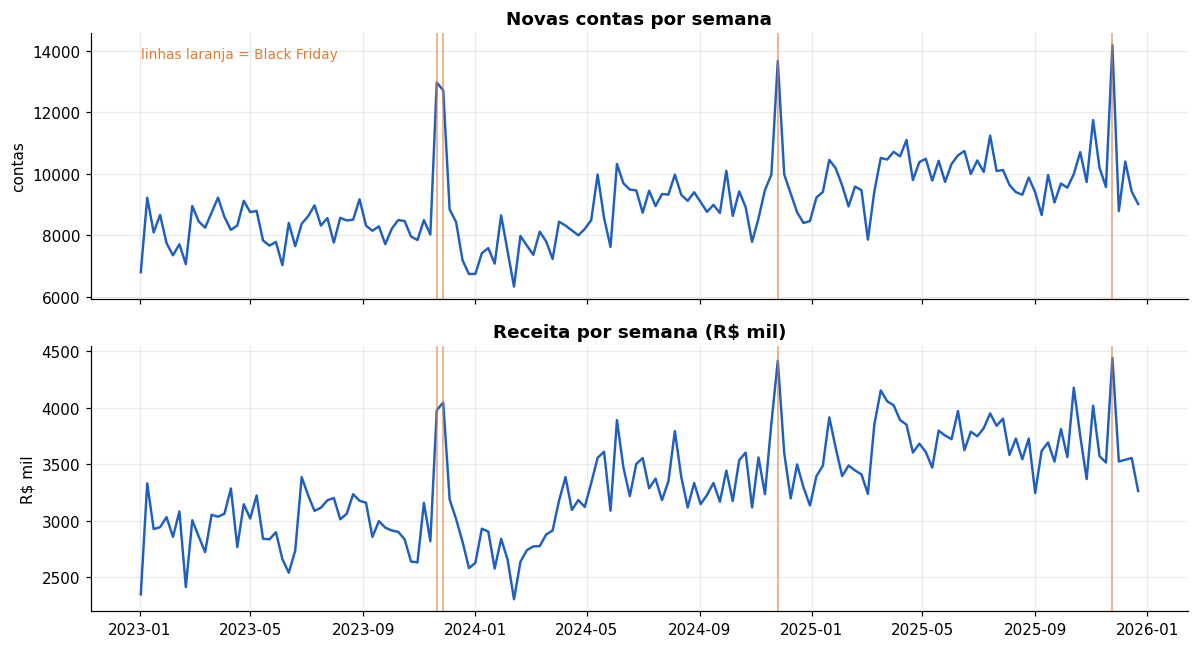

In [5]:
canais = ["google_search", "meta", "tiktok", "youtube", "afiliados", "display_programatico"]
datas = pd.to_datetime(df["semana"])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(datas, df["novas_contas"], color=AZUL, lw=1.6)
axes[0].set_title("Novas contas por semana"); axes[0].set_ylabel("contas")
axes[1].plot(datas, df["receita_mil"], color=AZUL, lw=1.6)
axes[1].set_title("Receita por semana (R$ mil)"); axes[1].set_ylabel("R$ mil")
# marca as semanas de Black Friday
for ax in axes:
    for d in datas[df["black_friday"] == 1]:
        ax.axvline(d, color=LARANJA, alpha=.6, lw=1.2)
axes[0].text(datas.iloc[0], df["novas_contas"].max() * .97, "linhas laranja = Black Friday", color=LARANJA, fontsize=9)
plt.tight_layout(); plt.show()

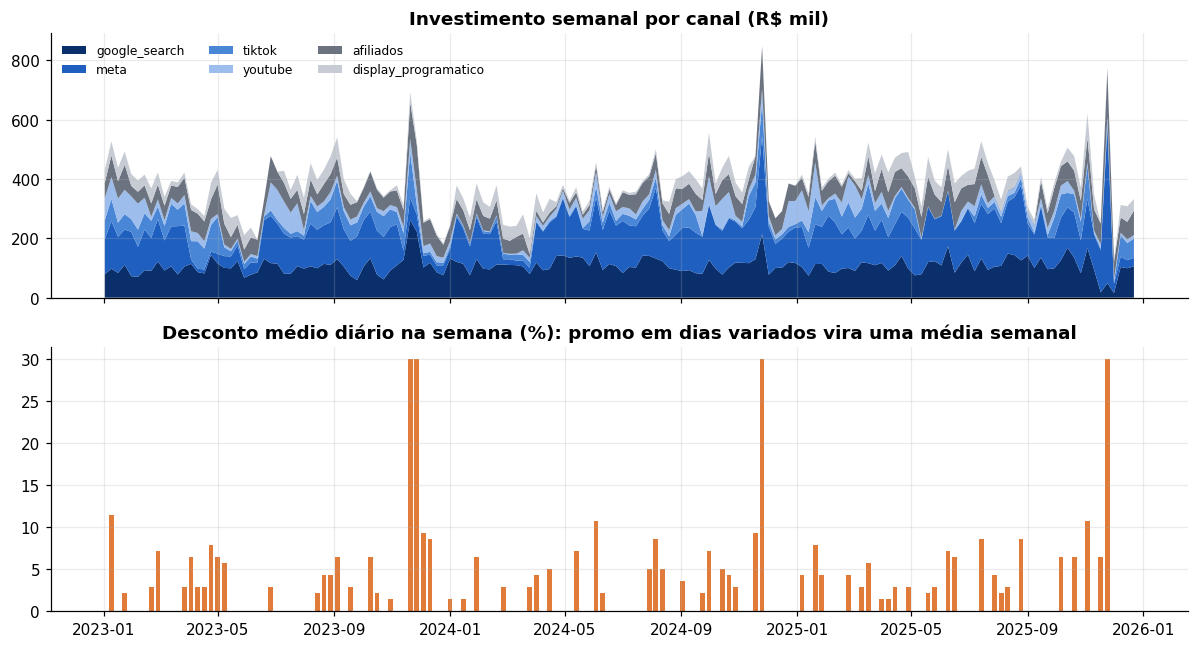

In [6]:
# Investimento empilhado por canal + desconto médio semanal
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
cores = ["#0b2f6b", AZUL, "#4a86d6", AZUL_CLARO, CINZA, "#c7ccd4"]
axes[0].stackplot(datas, [df[f"gasto_{c}"] for c in canais], labels=canais, colors=cores)
axes[0].set_title("Investimento semanal por canal (R$ mil)")
axes[0].legend(loc="upper left", ncol=3, fontsize=8, frameon=False)
axes[1].bar(datas, df["desconto_medio_pct"], width=5, color=LARANJA)
axes[1].set_title("Desconto médio diário na semana (%): promo em dias variados vira uma média semanal")
plt.tight_layout(); plt.show()

### 2.1 Multicolinearidade: correlações e VIF

O **VIF** (fator de inflação da variância) diz o quanto cada variável é "explicada" pelas outras. Regra prática: acima de ~5 já é preocupante, acima de 10 é grave. Calculo direto da matriz de correlação (o VIF de cada variável é a diagonal da inversa dessa matriz), sem depender de outra biblioteca.

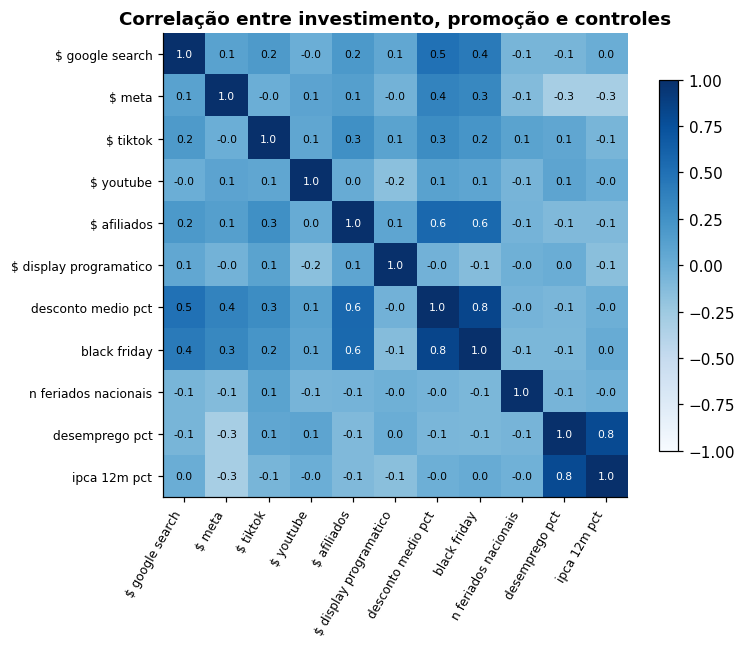

,gasto_google_search,gasto_meta,gasto_tiktok,gasto_youtube,gasto_afiliados,gasto_display_programatico,desconto_medio_pct,black_friday,n_feriados_nacionais,desemprego_pct,ipca_12m_pct
VIF,1.42,1.39,1.22,1.09,1.7,1.17,4.16,3.65,1.06,3.18,3.29


In [7]:
colunas_x = [f"gasto_{c}" for c in canais] + ["desconto_medio_pct", "black_friday", "n_feriados_nacionais", "desemprego_pct", "ipca_12m_pct"]
corr = df[colunas_x].corr()

# VIF = diagonal da inversa da matriz de correlação
vif = pd.Series(np.diag(np.linalg.inv(corr.values)), index=colunas_x, name="VIF").round(2)

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr.values, cmap="Blues", vmin=-1, vmax=1)
ax.set_xticks(range(len(colunas_x))); ax.set_yticks(range(len(colunas_x)))
rot = [c.replace("gasto_", "$ ").replace("_", " ") for c in colunas_x]
ax.set_xticklabels(rot, rotation=60, ha="right", fontsize=8); ax.set_yticklabels(rot, fontsize=8)
for i in range(len(colunas_x)):
    for j in range(len(colunas_x)):
        ax.text(j, i, f"{corr.values[i, j]:.1f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.values[i, j]) > .55 else "black")
ax.grid(False); ax.set_title("Correlação entre investimento, promoção e controles")
plt.colorbar(im, shrink=.8); plt.tight_layout(); plt.show()
vif.to_frame().T

**Como ler:** o investimento dos canais anda junto com o desconto e a Black Friday (as marcas costumam "empilhar" mídia em cima de promoção, e no dado sintético eu reproduzi isso de propósito). Ou seja: parte da venda que a mídia "leva o crédito" pode ser, na verdade, efeito da promoção. É por isso que promoção entra **no modelo como variável própria** e não fica de fora.

## 3. Adstock e saturação: o que o modelo está estimando

Dois conceitos deixam a mídia diferente de uma variável comum em regressão:

**Adstock (efeito acumulado/defasado).** Anúncio de hoje continua fazendo efeito nas semanas seguintes, com força decrescente. No Meridian o adstock é geométrico: o peso da semana *l* depois é proporcional a `decay^l`. `decay` baixo = efeito imediato (busca paga); `decay` alto = efeito longo (vídeo, marca).

**Saturação (curva de Hill).** Dobrar o investimento não dobra o resultado. A curva de Hill tem dois parâmetros: `ec` (o ponto em que se chega a metade do efeito máximo) e `slope` (o quão "em S" é a curva). Quanto mais perto do platô, menor o retorno do próximo real investido (o **ROI marginal**).

Uma ilustração com números do canal `youtube` do dado sintético:

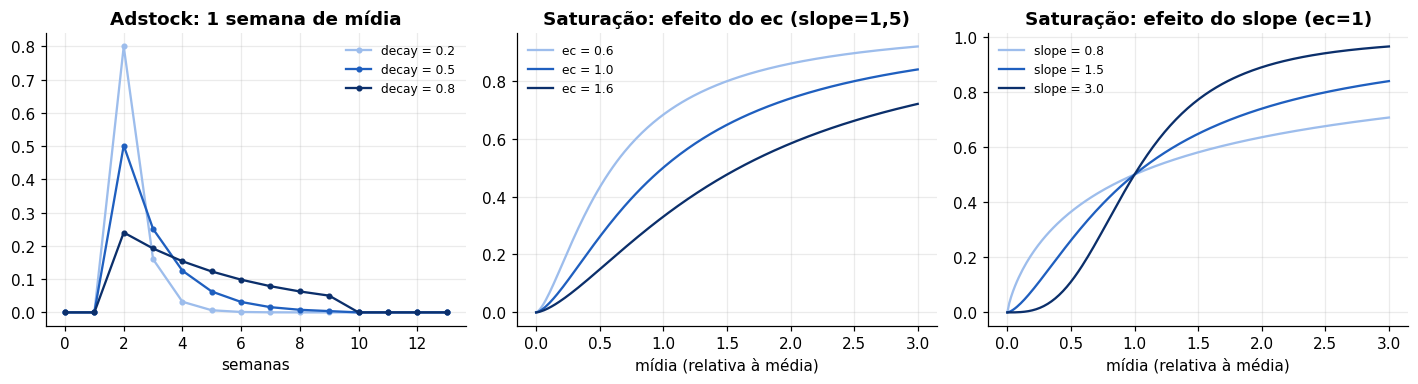

In [8]:
def adstock_geometrico(x, decay, max_lag=8):
    # pesos = decay^l, normalizados para somar 1 (mesma convenção do Meridian)
    pesos = decay ** np.arange(max_lag); pesos = pesos / pesos.sum()
    saida = np.zeros(len(x))
    for t in range(len(x)):
        for l in range(max_lag):
            if t - l >= 0:
                saida[t] += pesos[l] * x[t - l]
    return saida

def hill(x, ec, slope):
    # efeito entre 0 e 1: x^slope / (x^slope + ec^slope)
    return x ** slope / (x ** slope + ec ** slope)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# (a) Um "pulso" de mídia de 1 semana e o efeito diluído nas semanas seguintes
pulso = np.zeros(14); pulso[2] = 1
for dec, cor in [(0.2, AZUL_CLARO), (0.5, AZUL), (0.8, "#0b2f6b")]:
    axes[0].plot(adstock_geometrico(pulso, dec), marker="o", ms=3, color=cor, label=f"decay = {dec}")
axes[0].set_title("Adstock: 1 semana de mídia"); axes[0].set_xlabel("semanas"); axes[0].legend(frameon=False, fontsize=8)

# (b) Hill: efeito de mudar o ec (onde a curva "vira")
x = np.linspace(0, 3, 200)
for ec, cor in [(0.6, AZUL_CLARO), (1.0, AZUL), (1.6, "#0b2f6b")]:
    axes[1].plot(x, hill(x, ec, 1.5), color=cor, label=f"ec = {ec}")
axes[1].set_title("Saturação: efeito do ec (slope=1,5)"); axes[1].set_xlabel("mídia (relativa à média)"); axes[1].legend(frameon=False, fontsize=8)

# (c) Hill: efeito do slope
for sl, cor in [(0.8, AZUL_CLARO), (1.5, AZUL), (3.0, "#0b2f6b")]:
    axes[2].plot(x, hill(x, 1.0, sl), color=cor, label=f"slope = {sl}")
axes[2].set_title("Saturação: efeito do slope (ec=1)"); axes[2].set_xlabel("mídia (relativa à média)"); axes[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 4. O modelo ingênuo (e por que o MAPE sozinho engana)

Vou começar do jeito mais fácil: dados pro Meridian, priors padrão, sem calendário sazonal e deixando a tendência livre (o padrão do Meridian dá **um parâmetro de tendência/sazonalidade para cada semana**). É o que muita gente faz na primeira rodada.

Antes, uma função para carregar os dados no formato do Meridian.

### 4.1 Como o Meridian enxerga os dados

- **`media`** = impressões por canal; **`media_spend`** = gasto por canal (só para o cálculo de ROI).
- **`controls`** = variáveis que afetam o KPI mas não são mídia (macro, feriados...). Elas entram na conta do **baseline**.
- **`non_media_treatments`** = variáveis "tratamento" que não são mídia paga mas cuja contribuição queremos **isolar e medir** (aqui, o desconto): aparecem separadas na decomposição.
- `kpi_type`: `'non_revenue'` para volume (contas) ou `'revenue'` para dinheiro. Isso muda como o Meridian interpreta ROI: em `revenue`, ROI = R$ por R$ investido; em `non_revenue`, é KPI (contas) por unidade de gasto.

In [9]:
def carregar_dados_meridian(dados, coluna_kpi, tipo_kpi, controles):
    # Mapeia as colunas do DataFrame para os papéis que o Meridian espera.
    # Modelo NACIONAL: não passamos coluna de geo (uma única "região").
    c2c = load.CoordToColumns(
        time="semana",
        kpi=coluna_kpi,
        controls=controles,
        non_media_treatments=["desconto_medio_pct"],
        media=[f"impressoes_{c}" for c in canais],
        media_spend=[f"gasto_{c}" for c in canais],
    )
    loader = load.DataFrameDataLoader(
        df=dados,
        kpi_type=tipo_kpi,                                            # 'non_revenue' ou 'revenue'
        coord_to_columns=c2c,
        media_to_channel={f"impressoes_{c}": c for c in canais},      # nome amigável do canal
        media_spend_to_channel={f"gasto_{c}": c for c in canais},
    )
    return loader.load()

def ajustar(dados_meridian, model_spec):
    # Cria o modelo, amostra a prior (o que o modelo "acha" antes de ver dados)
    # e depois a posterior (o que acha depois de ver os dados) via MCMC.
    m = model.Meridian(input_data=dados_meridian, model_spec=model_spec)
    m.sample_prior(300)
    m.sample_posterior(n_chains=N_CHAINS, n_adapt=N_ADAPT, n_burnin=N_BURNIN, n_keep=N_KEEP, seed=SEED)
    return m

# Holdout: True nas semanas que ficam FORA do treino (as últimas SEMANAS_TESTE)
holdout = np.zeros(len(df), dtype=bool)
holdout[-SEMANAS_TESTE:] = True
print("Semanas de treino:", (~holdout).sum(), "| semanas de teste:", holdout.sum())
print("Teste começa em:", df.loc[holdout, "semana"].iloc[0])

Semanas de treino: 136 | semanas de teste: 20
Teste começa em: 2025-08-11


### 4.2 Configuração exata do modelo ingênuo

Tudo abaixo é o **padrão do Meridian**, exceto o holdout:

| Item | Ingênuo | (ajustado, seção 5) |
|---|---|---|
| Controles | 4: desemprego, IPCA, feriados, Black Friday | 10: os 4 + Fourier (2 harmônicos) + novembro/dezembro |
| Tendência (`knots`) | 1 por semana (156): baseline totalmente livre | 2 (uma reta) |
| Prior da mídia | KPI de volume sem receita: **contribuição total da mídia ~ 40% (desvio 20%)** | ROI por canal, LogNormal com 95% entre 1 e 25 contas por R$ 1 mil |
| Adstock (`alpha`) | Uniform(0, 1) por canal, `max_lag=8` | igual |
| Saturação | `ec` ~ Normal truncada(0,8; 0,8; 0,1 a 10); **`slope` fixo em 1** | igual |
| Holdout / MCMC | 20 semanas; mesmas cadeias | igual |

Documentação: [priors padrão](https://developers.google.com/meridian/docs/advanced-modeling/default-prior-distributions) e [KPI sem receita](https://developers.google.com/meridian/docs/advanced-modeling/unknown-revenue-kpi-default).

In [10]:
controles_basicos = ["desemprego_pct", "ipca_12m_pct", "n_feriados_nacionais", "black_friday"]
dados_contas_ingenuo = carregar_dados_meridian(df, "novas_contas", "non_revenue", controles_basicos)

# Modelo ingênuo: priors padrão do Meridian, tendência/sazonalidade livre (knots = 1 por semana, o padrão)
# Só passamos o holdout para termos MAPE de teste.
m_ing = ajustar(dados_contas_ingenuo, spec.ModelSpec(max_lag=8, holdout_id=holdout))

### 4.3 Diagnóstico e métricas

Duas coisas a checar em qualquer MMM bayesiano:

1. **Convergência (R-hat).** Cada parâmetro foi estimado por várias cadeias; se elas concordam, o R-hat fica perto de 1. Acima de ~1,1 a estimativa não é confiável.
2. **Acurácia: MAPE em treino e em teste.** Treino diz o quanto o modelo *se ajusta*; teste diz o quanto ele *generaliza* para semanas que nunca viu.

In [11]:
def diagnostico(m, titulo):
    a = analyzer.Analyzer(m)
    # R-hat por grupo de parâmetros; o que interessa é o max_r_hat
    rh = a.rhat_summary()[["param", "avg_r_hat", "max_r_hat", "percent_bad_r_hat"]]
    print(f"[{titulo}] maior R-hat entre todos os parâmetros: {rh['max_r_hat'].max():.3f}  (ideal < 1,1)")
    # Acurácia preditiva: MAPE / wMAPE / R² em treino, teste e total
    acc = a.predictive_accuracy().to_dataframe().reset_index()
    tab = acc.pivot(index="metric", columns="evaluation_set", values="value")[["Train", "Test", "All Data"]]
    tab.columns = ["Treino", "Teste", "Total"]
    return tab.loc[["MAPE", "wMAPE", "R_Squared"]].round(3)

diagnostico(m_ing, "ingênuo")

[ingênuo] maior R-hat entre todos os parâmetros: 1.012  (ideal < 1,1)


,Treino,Teste,Total
metric,,,
MAPE,0.041,0.055,0.042
wMAPE,0.040,0.054,0.042
R_Squared,0.862,0.690,0.853


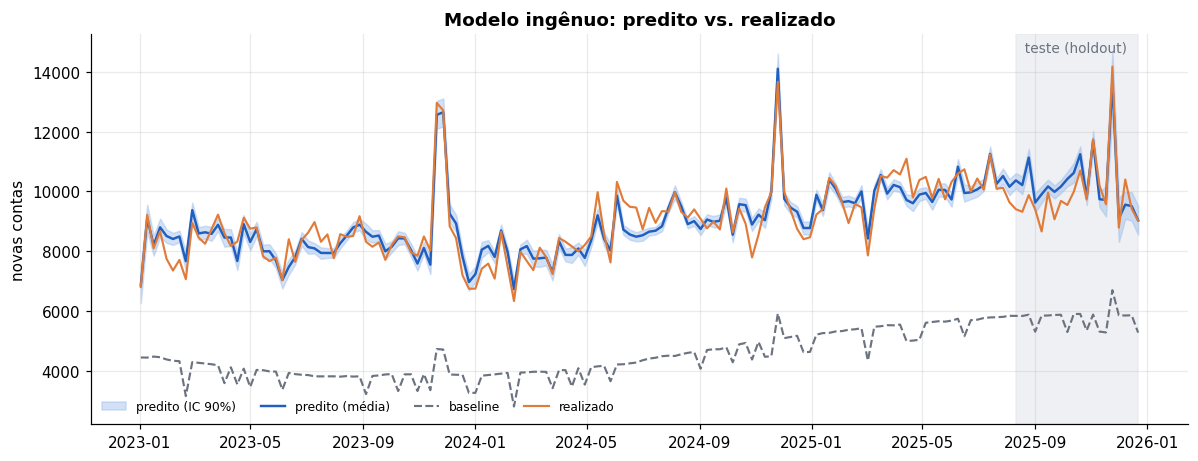

In [12]:
def plot_predito_vs_real(m, use_kpi, titulo, unidade):
    # Predito (média + intervalo de 90%), baseline e realizado ao longo do tempo.
    a = analyzer.Analyzer(m)
    ev = a.expected_vs_actual_data(aggregate_geos=True, use_kpi=use_kpi)
    t = pd.to_datetime(ev.time.values)
    exp_m, exp_lo, exp_hi = [ev.expected.sel(metric=k).values for k in ("mean", "ci_lo", "ci_hi")]
    base = ev.baseline.sel(metric="mean").values
    real = ev.actual.values

    fig, ax = plt.subplots(figsize=(11, 4.3))
    ax.fill_between(t, exp_lo, exp_hi, color=AZUL_CLARO, alpha=.45, label="predito (IC 90%)")
    ax.plot(t, exp_m, color=AZUL, lw=1.6, label="predito (média)")
    ax.plot(t, base, color=CINZA, lw=1.4, ls="--", label="baseline")
    ax.plot(t, real, color=LARANJA, lw=1.4, label="realizado")
    # área do teste
    ini = t[holdout][0]
    ax.axvspan(ini, t[-1], color="#e5e7eb", alpha=.6, zorder=0)
    ax.text(ini, ax.get_ylim()[1] * .985, "  teste (holdout)", va="top", fontsize=9, color=CINZA)
    ax.set_title(titulo); ax.set_ylabel(unidade); ax.legend(frameon=False, ncol=4, loc="lower left", fontsize=8)
    plt.tight_layout(); plt.show()

plot_predito_vs_real(m_ing, True, "Modelo ingênuo: predito vs. realizado", "novas contas")

### 4.4 Quem está recebendo o crédito? A decomposição da contribuição

Gráfico de barras horizontais com **quanto do KPI cada componente explica**: baseline (o que aconteceria sem mídia paga nem promoção), cada canal e o desconto.

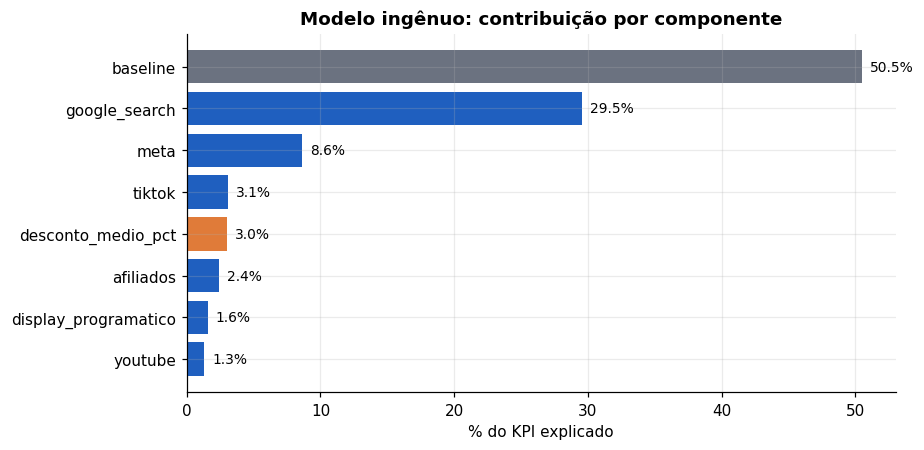

channel,youtube,display_programatico,afiliados,desconto_medio_pct,tiktok,meta,google_search,baseline
pct_of_contribution,1.3,1.6,2.4,3.0,3.1,8.6,29.5,50.5


In [13]:
def plot_contribuicao(m, use_kpi, titulo, verdade=None):
    # contribution_metrics devolve a % do KPI atribuída a cada componente (baseline, canais e non-media)
    ms = visualizer.MediaSummary(m, use_kpi=use_kpi)
    cm = ms.contribution_metrics(include_non_paid=True)
    cm = cm.sort_values("pct_of_contribution")
    cores_b = [CINZA if c == "baseline" else (LARANJA if c == "desconto_medio_pct" else AZUL) for c in cm["channel"]]
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.barh(cm["channel"], cm["pct_of_contribution"] * 100, color=cores_b)
    for i, v in enumerate(cm["pct_of_contribution"] * 100):
        ax.text(v + .6, i, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_xlabel("% do KPI explicado"); ax.set_title(titulo)
    plt.tight_layout(); plt.show()
    return cm

cm_ing = plot_contribuicao(m_ing, True, "Modelo ingênuo: contribuição por componente")
cm_ing.set_index("channel")[["pct_of_contribution"]].mul(100).round(1).T

> **Leitura do modelo ingênuo (números da minha execução).** O MAPE é de ~4% no treino e ~5,5% no teste. Parece um modelo aceitável, e é aqui que muita gente para. Mas olhe a decomposição: **`google_search` sozinho leva ~30% das novas contas** e o baseline só ~50%. Na seção 7 vamos conferir com o gabarito: o valor verdadeiro do Google é ~9%. Ou seja, **o ajuste é bom e a atribuição está errada.** A explicação mais provável: com tendência totalmente livre e priors abertos, o modelo tem liberdade demais para distribuir o crédito, e a busca paga (que sobe junto com sazonalidade e promoção) acaba levando o que não é dela. É o cenário do projeto original: MAPE ok, contribuição sem sentido de negócio.

## 5. Modelo ajustado: novas contas

Agora as decisões de modelagem que resolvem os problemas que apareceram. Cada uma com o motivo.

### 5.1 Decisões

1. **Sazonalidade explícita nos controles (Fourier + meses de pico).** Em vez de deixar o baseline livre para "aprender" a sazonalidade, eu **digo** a ele: ondas anuais (Fourier com 2 harmônicos) e um marcador para novembro e dezembro. Assim a sazonalidade deixa de disputar crédito com a mídia.
2. **Tendência simples: `knots=2`** (uma reta). Com uma tendência flexível demais o baseline vira "curinga". Com sazonalidade já controlada, a tendência só precisa ser suave, e isso faz o teste funcionar.
3. **Prior de ROI informado pelo negócio.** Em vez de deixar o modelo achar que um canal pode render de 0 a infinito, digo qual faixa é plausível: aqui, **de 1 a 25 contas por R$ 1 mil investido** (95% de probabilidade). É uma prior *larga*, só corta o absurdo. Em produção ela viria de experimentos de incrementalidade (geo-lift) ou de histórico.
4. **`max_lag=8`:** o efeito de uma semana de mídia pode durar até 8 semanas.
5. **Holdout de 20 semanas** para o MAPE de teste, como no projeto original.

In [14]:
# --- Sazonalidade explícita (calendário) --------------------------------------------------
df_aj = df.copy()
semana_ano = pd.to_datetime(df_aj["semana"]).dt.isocalendar().week.astype(int).values
for k in (1, 2):                                   # 2 harmônicos anuais (Fourier)
    df_aj[f"sen_{k}"] = np.sin(2 * np.pi * k * semana_ano / 52.18)
    df_aj[f"cos_{k}"] = np.cos(2 * np.pi * k * semana_ano / 52.18)
mes = pd.to_datetime(df_aj["semana"]).dt.month
df_aj["mes_nov"] = (mes == 11).astype(int)          # Black Friday e entorno
df_aj["mes_dez"] = (mes == 12).astype(int)          # Natal

controles_aj = ["desemprego_pct", "ipca_12m_pct", "n_feriados_nacionais", "black_friday",
                "sen_1", "cos_1", "sen_2", "cos_2", "mes_nov", "mes_dez"]

dados_contas = carregar_dados_meridian(df_aj, "novas_contas", "non_revenue", controles_aj)

# --- Prior de ROI: LogNormal com 95% da massa entre 1 e 25 contas por R$ mil ---------------
prior_contas = prior_distribution.PriorDistribution(
    roi_m=prior_distribution.lognormal_dist_from_range(1, 25)
)

spec_contas = spec.ModelSpec(prior=prior_contas, max_lag=8, knots=2, holdout_id=holdout)
m_contas = ajustar(dados_contas, spec_contas)

### 5.2 Diagnóstico e acurácia

In [15]:
diagnostico(m_contas, "contas ajustado")

[contas ajustado] maior R-hat entre todos os parâmetros: 1.035  (ideal < 1,1)


,Treino,Teste,Total
metric,,,
MAPE,0.030,0.033,0.030
wMAPE,0.029,0.032,0.030
R_Squared,0.931,0.888,0.931


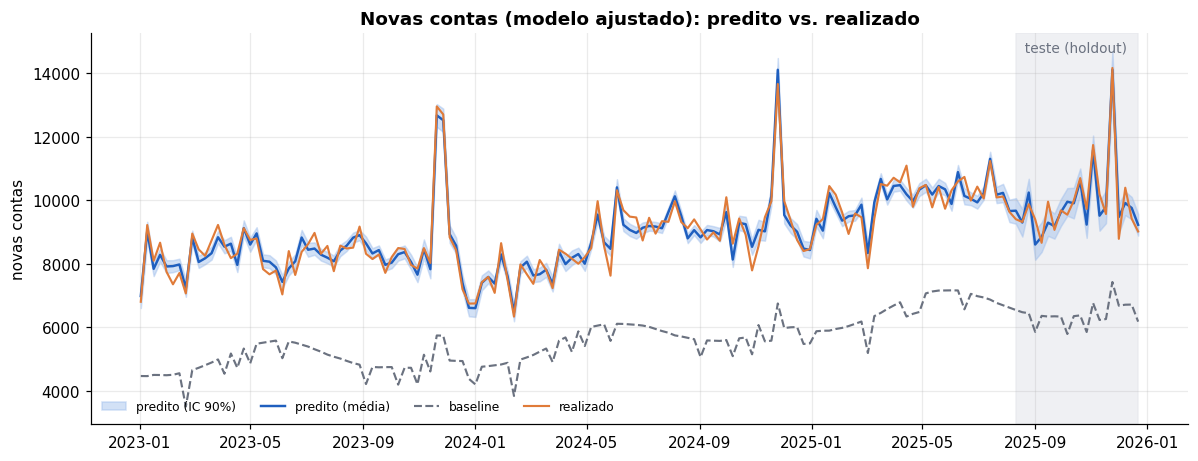

In [16]:
plot_predito_vs_real(m_contas, True, "Novas contas (modelo ajustado): predito vs. realizado", "novas contas")

### 5.3 Prior vs. posterior: o modelo aprendeu com os dados?

Se a posterior (azul) fica igual à prior, os dados não trouxeram informação sobre aquele canal. Se estreita e se desloca, o modelo aprendeu.

In [17]:
diag = visualizer.ModelDiagnostics(m_contas, use_kpi=True)
diag.plot_prior_and_posterior_distribution("roi_m")

alt.FacetChart(...)

In [18]:
diag.plot_rhat_boxplot()

alt.LayerChart(...)

### 5.4 Contribuição: baseline, canais e desconto

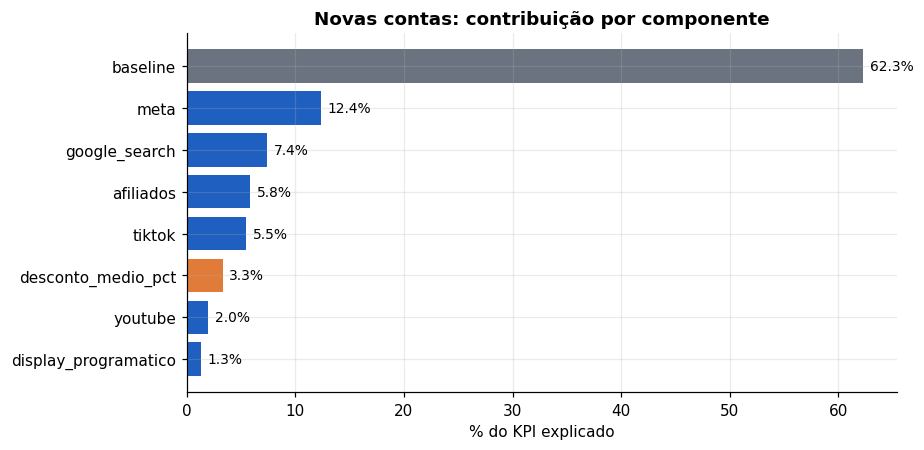

In [19]:
cm_contas = plot_contribuicao(m_contas, True, "Novas contas: contribuição por componente")

In [20]:
# Contribuição ao longo do tempo (área empilhada, por trimestre) e cascata do total
ms_contas = visualizer.MediaSummary(m_contas, use_kpi=True)
ms_contas.plot_channel_contribution_area_chart(time_granularity="quarterly")

alt.Chart(...)

In [21]:
ms_contas.plot_contribution_waterfall_chart()

alt.LayerChart(...)

### 5.4b Dentro do baseline: o que fazem os controles

O Meridian entrega o baseline inteiro, mas não a contribuição de cada controle. Ela sai dos **coeficientes da posterior** (`gamma`): para cada semana,

`contribuição do controle k = desvio-padrão do KPI × gamma_k × controle_k padronizado`

Como os controles são **centrados** (média zero), a contribuição é o **desvio em relação ao nível médio**: positiva quando o fator empurra o KPI para cima naquela semana, negativa quando puxa para baixo. O que sobra do baseline (nível médio + tendência) é a diferença entre o baseline do Meridian e a soma dos controles. Ver [documentação do baseline](https://developers.google.com/meridian/docs/post-modeling/baseline).

In [22]:
def decompor_baseline(m, use_kpi, controles):
    a = analyzer.Analyzer(m)
    post = m.inference_data.posterior
    # desvio-padrão do KPI usado pelo Meridian para padronizar (1 número, em unidades do KPI)
    sd_kpi = float(np.asarray(m.kpi_transformer.population_scaled_stdev).ravel()[0])
    z = np.asarray(m.controls_scaled)[0]                       # controles padronizados: (semanas, controles)
    g = np.asarray(post["gamma_gc"].values)[:, :, 0, :]        # coeficientes: (cadeia, amostra, controle)
    # contribuição de cada controle em cada semana, para cada amostra da posterior
    contrib = sd_kpi * np.einsum("cdk,tk->cdkt", g, z)         # (cadeia, amostra, controle, semana)

    linhas = []
    for k, c in enumerate(controles):
        x = df_aj[c].values.astype(float)
        sd_c = 1.0 / np.polyfit(x, z[:, k], 1)[0]               # desvio-padrão do controle (escala original)
        efeito_un = sd_kpi * g[:, :, k].ravel() / sd_c          # KPI por +1 unidade do controle
        linhas.append(dict(controle=c, efeito_por_unidade=efeito_un.mean(),
                           ic90_baixo=np.quantile(efeito_un, .05), ic90_alto=np.quantile(efeito_un, .95),
                           sinal="incerto (IC inclui 0)" if np.quantile(efeito_un, .05) < 0 < np.quantile(efeito_un, .95)
                                 else ("positivo" if efeito_un.mean() > 0 else "negativo")))
    tabela = pd.DataFrame(linhas).set_index("controle")

    ev = a.expected_vs_actual_data(aggregate_geos=True, use_kpi=use_kpi)
    baseline = ev.baseline.sel(metric="mean").values
    contrib_med = contrib.mean(axis=(0, 1))                     # média sobre as amostras: (controle, semana)
    serie = pd.DataFrame(contrib_med.T, columns=controles)
    serie.insert(0, "nivel_tendencia", baseline - contrib_med.sum(axis=0))
    serie.insert(0, "baseline", baseline)
    serie.index = pd.to_datetime(df["semana"])
    return tabela.round(1), serie

tab_ctrl, serie_base = decompor_baseline(m_contas, True, controles_aj)
tab_ctrl

,efeito_por_unidade,ic90_baixo,ic90_alto,sinal
controle,,,,
desemprego_pct,-727.5,-1988.2,488.1,incerto (IC inclui 0)
ipca_12m_pct,-296.7,-486.9,-112.7,negativo
n_feriados_nacionais,-543.3,-654.0,-428.8,negativo
black_friday,589.8,-76.7,1286.7,incerto (IC inclui 0)
sen_1,326.3,113.4,546.4,positivo
cos_1,-544.5,-762.8,-335.5,negativo
sen_2,-137.2,-240.2,-37.3,negativo
cos_2,79.3,-33.8,183.1,incerto (IC inclui 0)
mes_nov,357.0,4.8,721.5,positivo


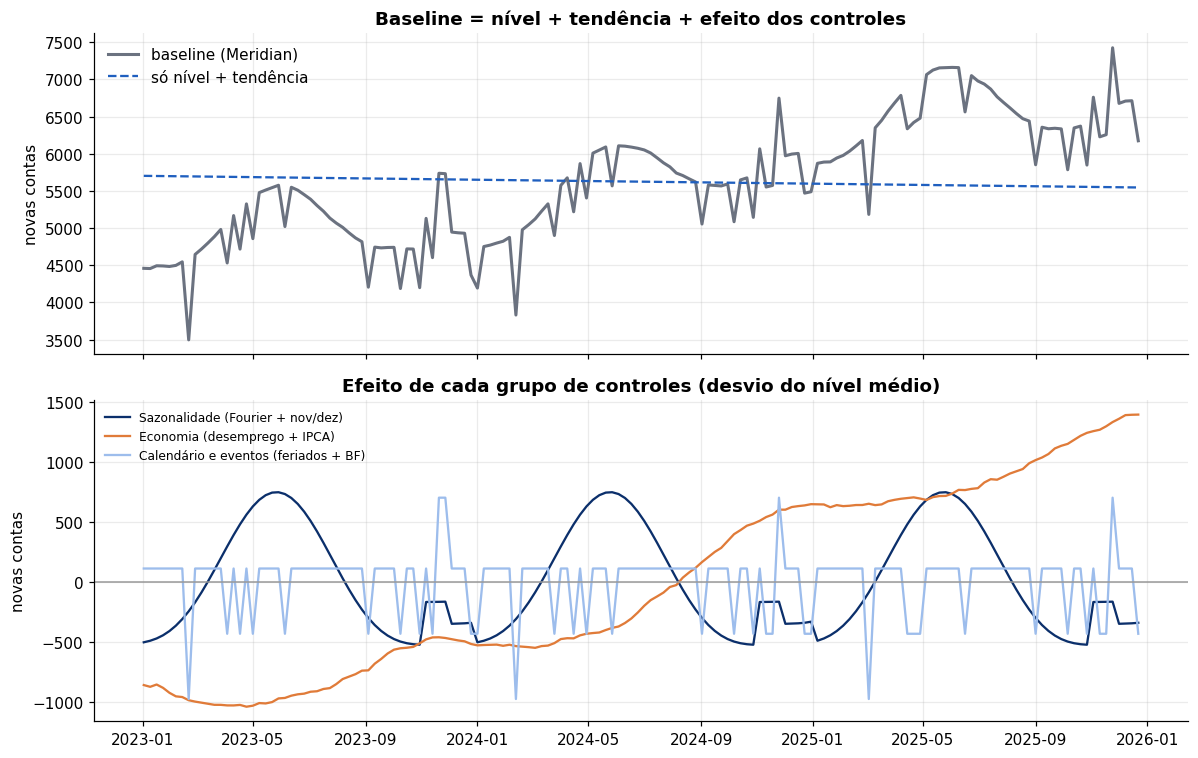

In [23]:
grupos = {"Sazonalidade (Fourier + nov/dez)": ["sen_1", "cos_1", "sen_2", "cos_2", "mes_nov", "mes_dez"],
          "Economia (desemprego + IPCA)": ["desemprego_pct", "ipca_12m_pct"],
          "Calendário e eventos (feriados + BF)": ["n_feriados_nacionais", "black_friday"]}

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(serie_base.index, serie_base["baseline"], color=CINZA, lw=2, label="baseline (Meridian)")
axes[0].plot(serie_base.index, serie_base["nivel_tendencia"], color=AZUL, ls="--", label="só nível + tendência")
axes[0].set_title("Baseline = nível + tendência + efeito dos controles"); axes[0].set_ylabel("novas contas"); axes[0].legend(frameon=False)
for (g, cs), cor in zip(grupos.items(), ["#0b2f6b", LARANJA, AZUL_CLARO]):
    axes[1].plot(serie_base.index, serie_base[cs].sum(axis=1), color=cor, label=g)
axes[1].axhline(0, color="#999", lw=1)
axes[1].set_title("Efeito de cada grupo de controles (desvio do nível médio)"); axes[1].set_ylabel("novas contas"); axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**Como ler.** A linha tracejada de cima (só nível + tendência) pode ficar quase **plana** enquanto o efeito de *Economia* sobe de forma contínua. Como o desemprego cai devagar durante os 3 anos, **tendência de crescimento e efeito do desemprego são praticamente indistinguíveis**: o modelo estima bem o baseline total, mas a divisão entre os dois é incerta (repare no intervalo largo do desemprego na tabela). Já o IPCA e os feriados têm efeito claramente negativo, como esperado.

### 5.5 Retorno por canal: ROI, custo por conta (CAC) e ROI marginal

- **ROI** aqui = novas contas por R$ 1 mil investido. O inverso, `1000 / ROI`, é o **CAC** (custo por conta) em R$.
- **ROI marginal (mROI)** = contas adicionais que o *próximo* R$ 1 mil traria. Se mROI << ROI, o canal está **saturando**: o dinheiro extra rende muito menos que o médio.
- A coluna de intervalos (IC 90%) mostra a incerteza. Canais com intervalo largo não devem ter decisão tomada só pelo ponto.

In [24]:
def tabela_retorno(m, use_kpi, kpi_nome):
    a = analyzer.Analyzer(m)
    sm = a.summary_metrics(use_kpi=use_kpi)
    post = lambda var, met: sm[var].sel(metric=met, distribution="posterior").to_series()
    tab = pd.DataFrame({
        "gasto_R$mil": sm["spend"].to_series(),
        "roi_medio": post("roi", "mean"),
        "roi_ic90_baixo": post("roi", "ci_lo"),
        "roi_ic90_alto": post("roi", "ci_hi"),
        "mroi": post("mroi", "mean"),
    })
    tab = tab.drop(index="All Channels", errors="ignore")
    tab["mroi/roi"] = tab["mroi"] / tab["roi_medio"]
    # Alerta de saturação (convenção deste projeto, é uma regra prática, não um teste estatístico):
    #   mroi/roi < 0,40  -> saturada   (o próximo real rende menos de 40% do real médio)
    #   0,40 a 0,50      -> atenção
    #   > 0,50           -> com espaço
    tab["saturacao"] = np.select([tab["mroi/roi"] < 0.40, tab["mroi/roi"] <= 0.50], ["saturada", "atenção"], default="com espaço")
    if kpi_nome == "novas_contas":
        tab["CAC_R$"] = 1000 / tab["roi_medio"]
    return tab.round(2)

tab_contas = tabela_retorno(m_contas, True, "novas_contas")
tab_contas

,gasto_R$mil,roi_medio,roi_ic90_baixo,roi_ic90_alto,mroi,mroi/roi,saturacao,CAC_R$
channel,,,,,,,,
google_search,16799.29,6.20,1.45,13.90,2.78,0.45,atenção,161.22
meta,19493.06,8.95,5.60,13.16,4.51,0.50,com espaço,111.79
tiktok,5846.23,13.17,8.30,18.60,5.95,0.45,atenção,75.90
youtube,4459.87,6.28,1.76,12.43,2.47,0.39,saturada,159.30
afiliados,8448.12,9.71,4.05,16.17,4.92,0.51,com espaço,103.02
display_programatico,4844.94,3.90,1.16,8.04,1.68,0.43,atenção,256.60


In [25]:
ms_contas.plot_roi_bar_chart(include_ci=True)

alt.LayerChart(...)

### 5.6 Curvas de resposta, adstock e Hill

- **Curva de resposta**: KPI incremental (eixo Y) em função do investimento (eixo X). O ponto de operação atual é o multiplicador 1,0. Curva ainda subindo = há espaço; achatando = saturação.
- **Decay do adstock**: quanto do efeito de uma semana sobrevive nas seguintes.
- **Curvas de Hill**: o formato da saturação de cada canal, com a distribuição da prior ao fundo.

In [26]:
efeitos = visualizer.MediaEffects(m_contas, use_kpi=True)
efeitos.plot_response_curves(confidence_level=0.9, plot_separately=True, num_channels_displayed=6)

alt.FacetChart(...)

In [27]:
efeitos.plot_adstock_decay()

alt.FacetChart(...)

In [28]:
hill_charts = efeitos.plot_hill_curves()
hill_charts["google_search"] if "google_search" in hill_charts else list(hill_charts.values())[0]

alt.FacetChart(...)

## 6. Modelo ajustado: receita

Mesmo método, agora com **receita** como KPI (`kpi_type='revenue'`). Muda a prior de ROI: passa a ser **R$ de receita por R$ 1 investido**, e a faixa plausível é outra (aqui, entre 0,3 e 8).

Nada mais muda: mesmos controles, mesma tendência, mesmo holdout. Assim a diferença entre os dois modelos vem só do KPI.

In [29]:
dados_receita = carregar_dados_meridian(df_aj, "receita_mil", "revenue", controles_aj)
prior_receita = prior_distribution.PriorDistribution(
    roi_m=prior_distribution.lognormal_dist_from_range(0.3, 8)   # R$ de receita por R$ 1 de mídia
)
m_rec = ajustar(dados_receita, spec.ModelSpec(prior=prior_receita, max_lag=8, knots=2, holdout_id=holdout))
diagnostico(m_rec, "receita ajustado")

[receita ajustado] maior R-hat entre todos os parâmetros: 1.041  (ideal < 1,1)


,Treino,Teste,Total
metric,,,
MAPE,0.029,0.030,0.029
wMAPE,0.029,0.032,0.029
R_Squared,0.923,0.656,0.916


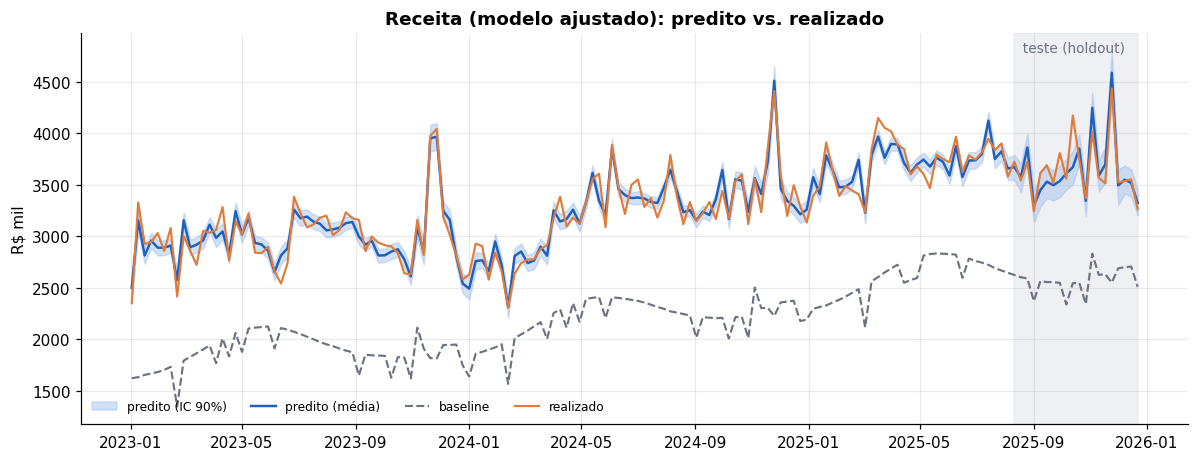

In [30]:
plot_predito_vs_real(m_rec, False, "Receita (modelo ajustado): predito vs. realizado", "R$ mil")

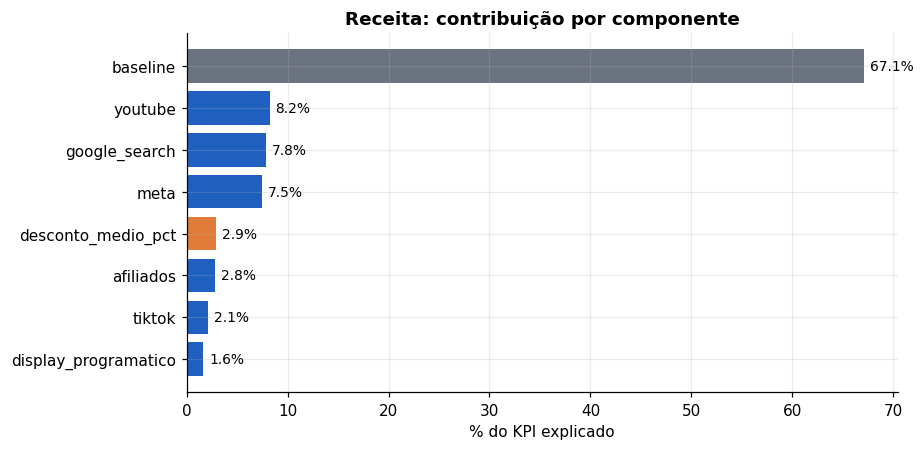

,gasto_R$mil,roi_medio,roi_ic90_baixo,roi_ic90_alto,mroi,mroi/roi,saturacao
channel,,,,,,,
google_search,16799.29,2.40,0.54,5.73,1.12,0.47,atenção
meta,19493.06,1.97,1.08,3.12,1.01,0.51,com espaço
tiktok,5846.23,1.88,0.55,3.63,0.80,0.42,atenção
youtube,4459.87,9.48,6.62,12.77,4.29,0.45,atenção
afiliados,8448.12,1.69,0.45,3.47,0.77,0.46,atenção
display_programatico,4844.94,1.73,0.48,3.56,0.82,0.47,atenção


In [31]:
cm_rec = plot_contribuicao(m_rec, False, "Receita: contribuição por componente")
tab_rec = tabela_retorno(m_rec, False, "receita")
tab_rec

In [32]:
ms_rec = visualizer.MediaSummary(m_rec, use_kpi=False)
ms_rec.plot_roi_bar_chart(include_ci=True)

alt.LayerChart(...)

In [33]:
efeitos_rec = visualizer.MediaEffects(m_rec, use_kpi=False)
efeitos_rec.plot_response_curves(confidence_level=0.9, plot_separately=True, num_channels_displayed=6)

alt.FacetChart(...)

### 6.1 O mesmo canal pode ser bom para conta e ruim para receita

Comparando os dois modelos lado a lado (os canais mudam de posição no ranking):

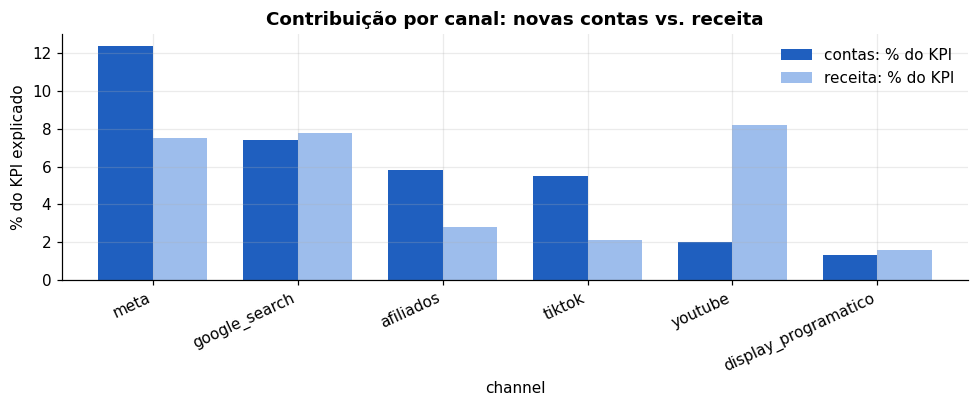

,contas: % do KPI,receita: % do KPI
channel,,
meta,12.4,7.5
google_search,7.4,7.8
afiliados,5.8,2.8
tiktok,5.5,2.1
youtube,2.0,8.2
display_programatico,1.3,1.6


In [34]:
comp = pd.DataFrame({
    "contas: % do KPI": cm_contas.set_index("channel")["pct_of_contribution"] * 100,
    "receita: % do KPI": cm_rec.set_index("channel")["pct_of_contribution"] * 100,
}).drop(index=["baseline", "desconto_medio_pct"], errors="ignore").sort_values("contas: % do KPI", ascending=False).round(1)

comp.plot(kind="bar", figsize=(9, 3.8), color=[AZUL, AZUL_CLARO], width=.75)
plt.ylabel("% do KPI explicado"); plt.title("Contribuição por canal: novas contas vs. receita")
plt.xticks(rotation=25, ha="right"); plt.legend(frameon=False); plt.tight_layout(); plt.show()
comp

## 7. Verdade vs. estimado: o modelo recuperou o que plantamos?

Como o dado é sintético, temos o "gabarito". Comparo, para cada canal: **contribuição (%)**, **ROI** e **decay do adstock**. E depois as **curvas de resposta** estimadas contra as verdadeiras.

Cuidados com a comparação:
- A verdade é a soma da contribuição de cada canal ao longo das 156 semanas, na mesma escala do KPI.
- O `ec`/`slope` do Meridian estão na escala interna dele (mídia normalizada), então **não comparo os números crus**: comparo a **forma da curva** em R$ investido, que é o que importa para decisão.

In [35]:
verdade = ler_arquivo("verdade_conhecida.json", lambda p: json.load(open(p)) if os.path.exists(p) else __import__("requests").get(p).json())

def recuperacao(m, use_kpi, chave):
    a = analyzer.Analyzer(m)
    sm = a.summary_metrics(use_kpi=use_kpi)
    est = lambda var, met: sm[var].sel(metric=met, distribution="posterior").to_series().drop("All Channels")
    # decay estimado: alpha_m da posterior (média entre cadeias e amostras)
    alpha = m.inference_data.posterior["alpha_m"].mean(dim=["chain", "draw"]).to_series()
    alpha.index = [canais[i] if isinstance(i, (int, np.integer)) else i for i in alpha.index]
    v = verdade[chave]["canais"]
    tab = pd.DataFrame({
        "contrib_verdade_%": {c: v[c]["contribuicao_pct"] * 100 for c in canais},
        "contrib_estimada_%": est("pct_of_contribution", "mean"),
        "ic90_baixo_%": est("pct_of_contribution", "ci_lo"),
        "ic90_alto_%": est("pct_of_contribution", "ci_hi"),
        "roi_verdade": {c: v[c]["roi"] for c in canais},
        "roi_estimado": est("roi", "mean"),
        "decay_verdade": {c: v[c]["decay"] for c in canais},
        "decay_estimado": alpha,
    })
    return tab.round(2)

rec_contas = recuperacao(m_contas, True, "novas_contas")
rec_receita = recuperacao(m_rec, False, "receita_mil")
print("NOVAS CONTAS"); display(rec_contas)
print("RECEITA");      display(rec_receita)

NOVAS CONTAS


,contrib_verdade_%,contrib_estimada_%,ic90_baixo_%,ic90_alto_%,roi_verdade,roi_estimado,decay_verdade,decay_estimado
google_search,9.20,7.40,1.74,16.58,7.72,6.20,0.20,0.43
meta,6.94,12.38,7.76,18.22,5.01,8.95,0.45,0.62
tiktok,4.52,5.47,3.45,7.72,10.89,13.17,0.50,0.32
youtube,2.69,1.99,0.56,3.94,8.51,6.28,0.65,0.41
afiliados,7.56,5.82,2.43,9.70,12.61,9.71,0.15,0.25
display_programatico,2.04,1.34,0.40,2.77,5.93,3.90,0.40,0.41


RECEITA


,contrib_verdade_%,contrib_estimada_%,ic90_baixo_%,ic90_alto_%,roi_verdade,roi_estimado,decay_verdade,decay_estimado
google_search,8.29,7.82,1.76,18.69,2.54,2.40,0.20,0.47
meta,4.81,7.47,4.07,11.80,1.27,1.97,0.45,0.41
tiktok,2.61,2.14,0.63,4.12,2.30,1.88,0.50,0.41
youtube,5.48,8.21,5.74,11.07,6.32,9.48,0.65,0.55
afiliados,2.39,2.78,0.74,5.69,1.45,1.69,0.15,0.36
display_programatico,1.43,1.63,0.46,3.35,1.53,1.73,0.40,0.43


### 7.0 O modelo ingênuo contra a verdade

Agora dá para responder objetivamente se as decisões de modelagem da seção 5 valeram a pena: erro absoluto médio da **contribuição por canal** (em pontos percentuais do KPI) e a fatia atribuída ao baseline, para o modelo ingênuo e o ajustado.

In [36]:
rec_ing = recuperacao(m_ing, True, "novas_contas")
erro = pd.DataFrame({
    "ingênuo (erro abs., p.p.)":  (rec_ing["contrib_estimada_%"]    - rec_ing["contrib_verdade_%"]).abs(),
    "ajustado (erro abs., p.p.)": (rec_contas["contrib_estimada_%"] - rec_contas["contrib_verdade_%"]).abs(),
})
erro.loc["MÉDIA"] = erro.mean()

# fatia total atribuída à mídia paga (soma dos canais)
midia_verdade = verdade["novas_contas"]["midia_total"] / verdade["novas_contas"]["y_total"] * 100
def midia_pct(m):
    cm = visualizer.MediaSummary(m, use_kpi=True).contribution_metrics(include_non_paid=True).set_index("channel")
    return cm.loc[canais, "pct_of_contribution"].sum() * 100
print(f"Mídia paga (soma dos canais): verdade {midia_verdade:.1f}% | ingênuo {midia_pct(m_ing):.1f}% | ajustado {midia_pct(m_contas):.1f}%")
erro.round(2)

Mídia paga (soma dos canais): verdade 32.9% | ingênuo 46.5% | ajustado 34.4%


,"ingênuo (erro abs., p.p.)","ajustado (erro abs., p.p.)"
google_search,20.32,1.80
meta,1.66,5.44
tiktok,1.40,0.95
youtube,1.39,0.70
afiliados,5.17,1.74
display_programatico,0.47,0.70
MÉDIA,5.07,1.89


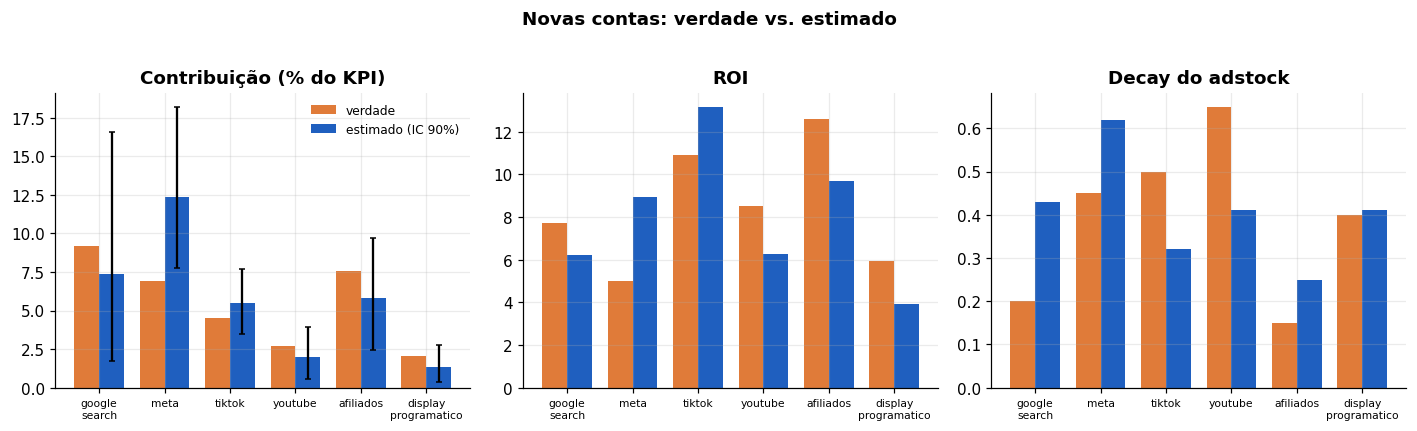

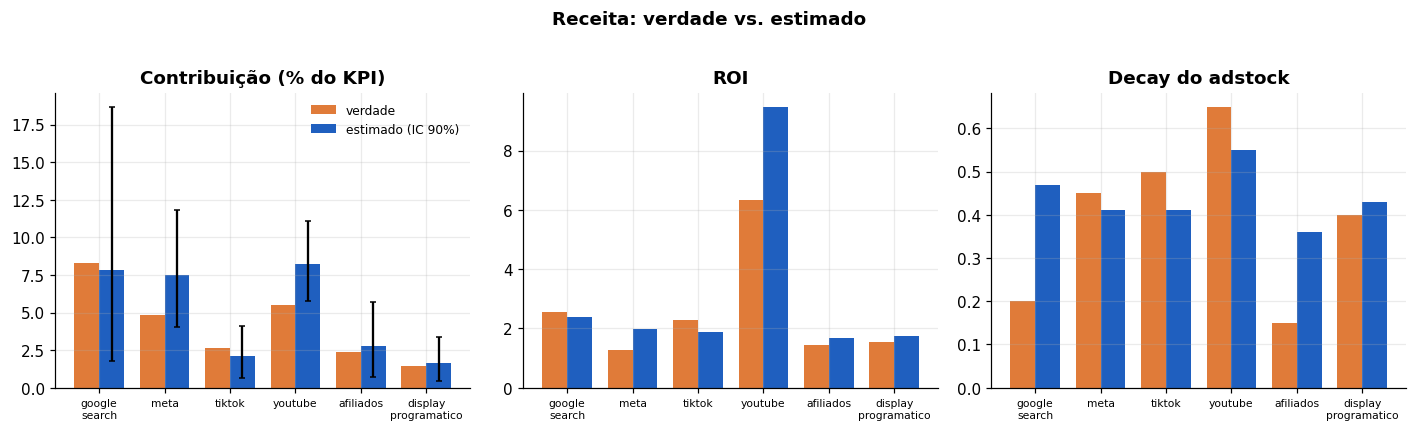

In [37]:
def plot_recuperacao(tab, titulo):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    x = np.arange(len(tab)); w = .38
    rot = [c.replace("_", "\n") for c in tab.index]
    # contribuição %
    erro = [tab["contrib_estimada_%"] - tab["ic90_baixo_%"], tab["ic90_alto_%"] - tab["contrib_estimada_%"]]
    axes[0].bar(x - w/2, tab["contrib_verdade_%"], w, color=LARANJA, label="verdade")
    axes[0].bar(x + w/2, tab["contrib_estimada_%"], w, color=AZUL, yerr=erro, capsize=2, label="estimado (IC 90%)")
    axes[0].set_title("Contribuição (% do KPI)")
    # ROI
    axes[1].bar(x - w/2, tab["roi_verdade"], w, color=LARANJA, label="verdade")
    axes[1].bar(x + w/2, tab["roi_estimado"], w, color=AZUL, label="estimado")
    axes[1].set_title("ROI")
    # decay
    axes[2].bar(x - w/2, tab["decay_verdade"], w, color=LARANJA, label="verdade")
    axes[2].bar(x + w/2, tab["decay_estimado"], w, color=AZUL, label="estimado")
    axes[2].set_title("Decay do adstock")
    for ax in axes:
        ax.set_xticks(x); ax.set_xticklabels(rot, fontsize=7)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(titulo, fontweight="bold", y=1.02); plt.tight_layout(); plt.show()

plot_recuperacao(rec_contas, "Novas contas: verdade vs. estimado")
plot_recuperacao(rec_receita, "Receita: verdade vs. estimado")

### 7.1 Curvas de resposta: estimada vs. verdadeira

A curva verdadeira é calculada com a mesma fórmula do gerador (adstock, depois Hill), aplicada a cada multiplicador de investimento. O KPI incremental é somado nas 156 semanas.

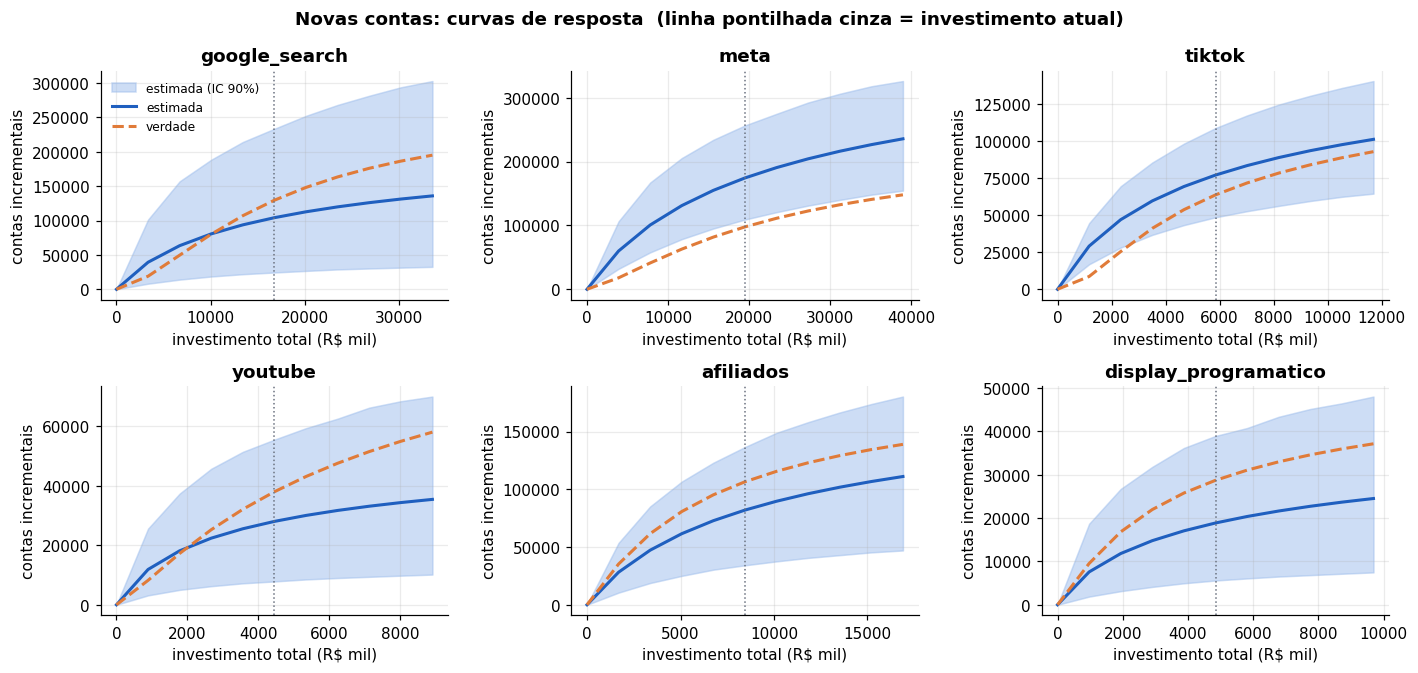

In [38]:
def curva_verdadeira(canal, chave, multiplicadores):
    v = verdade[chave]["canais"][canal]
    gasto = df[f"gasto_{canal}"].values
    media = gasto.mean()
    saida = []
    for k in multiplicadores:
        xa = adstock_geometrico(k * gasto / media, v["decay"])
        saida.append((v["beta"] * hill(xa, v["ec"], v["slope"])).sum())
    return np.array(saida)

def plot_curvas(m, use_kpi, chave, titulo, unidade):
    a = analyzer.Analyzer(m)
    rc = a.response_curves(use_kpi=use_kpi, spend_multipliers=list(np.round(np.arange(0, 2.01, 0.2), 1)))
    mult = rc.spend_multiplier.values
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.2), sharex=False)
    for ax, c in zip(axes.ravel(), canais):
        gasto = rc.spend.sel(channel=c).values
        m_, lo, hi = [rc.incremental_outcome.sel(channel=c, metric=k).values for k in ("mean", "ci_lo", "ci_hi")]
        ax.fill_between(gasto, lo, hi, color=AZUL_CLARO, alpha=.5, label="estimada (IC 90%)")
        ax.plot(gasto, m_, color=AZUL, lw=2, label="estimada")
        ax.plot(gasto, curva_verdadeira(c, chave, mult), color=LARANJA, lw=2, ls="--", label="verdade")
        ax.axvline(gasto[list(mult).index(1.0)], color=CINZA, lw=1, ls=":")
        ax.set_title(c); ax.set_xlabel("investimento total (R$ mil)"); ax.set_ylabel(unidade)
    axes[0, 0].legend(frameon=False, fontsize=8)
    fig.suptitle(titulo + "  (linha pontilhada cinza = investimento atual)", fontweight="bold")
    plt.tight_layout(); plt.show()

plot_curvas(m_contas, True, "novas_contas", "Novas contas: curvas de resposta", "contas incrementais")

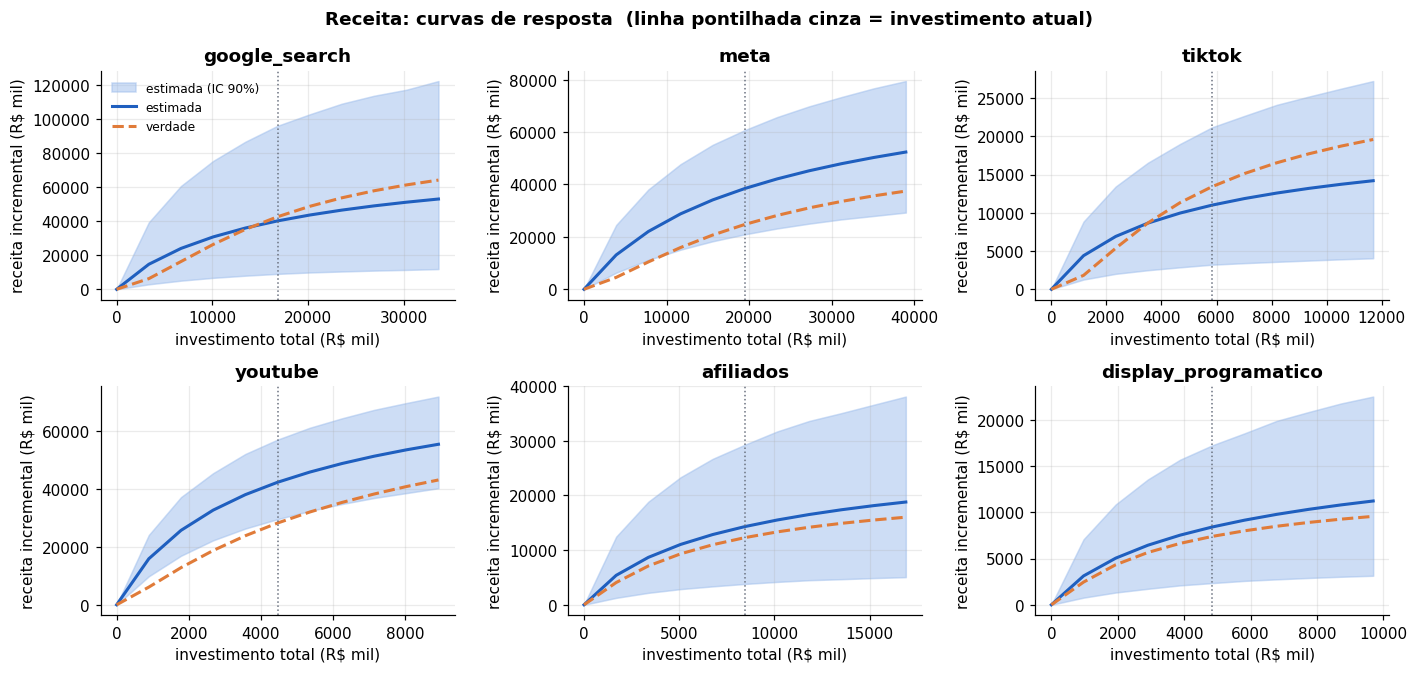

In [39]:
plot_curvas(m_rec, False, "receita_mil", "Receita: curvas de resposta", "receita incremental (R$ mil)")

## 8. Quando investir: bomba ou diluído? Tudo em 1 mês ou espalhado no ano?

Duas perguntas do projeto original, respondidas com o modelo ajustado:

1. Vale mais investir uma **"bomba"** de uma vez ou **aos poucos ao longo das semanas**?
2. É melhor investir **tudo em 1 mês** ou **diluir em outros meses**?

**Método.** Fixo uma **verba** (a média semanal normal de cada canal × o número de semanas do período) e comparo **cronogramas** diferentes para gastar exatamente essa verba. Para cada cronograma, o Meridian calcula o KPI incremental com as amostras da posterior (`incremental_outcome` com `new_data`, isto é, uma mídia hipotética). Assim cada resultado vem com intervalo. O cenário **diluído** é o 100 de referência. Como o dado é sintético, calculo também o resultado **verdadeiro** com a fórmula do gerador.

**Por que diluir tende a ganhar:** a saturação (Hill) faz cada real a mais render menos, então concentrar verba empurra o canal para o platô. O adstock espalha parte do efeito no tempo, mas não compensa isso.

**Limites:** o modelo assume que o efeito de uma impressão é o mesmo em qualquer época do ano e que o CPM não muda (na Black Friday ele sobe): **não** avalia se vale concentrar verba em época de demanda alta. E cronogramas com pico muito acima do máximo semanal já observado são **extrapolação**.

In [40]:
def cenarios(T):
    # pesos (somam 1) de como a verba de T semanas é distribuída no tempo
    def primeiras(n):
        v = np.zeros(T); v[:n] = 1; return v / v.sum()
    def blocos(on, off):
        v = np.zeros(T); i = 0
        while i < T:
            v[i:i + on] = 1; i += on + off
        return v / v.sum()
    if T == 13:   # pergunta 1: dentro de um trimestre
        return {"Diluído: 13 semanas iguais": primeiras(13), "8 semanas seguidas": primeiras(8),
                "1 mês seguido (4 semanas)": primeiras(4), "2 semanas seguidas": primeiras(2),
                "Bomba: 1 semana só": primeiras(1), "Pulsos: 1 semana sim, 1 não": blocos(1, 1)}
    return {"Diluído: 52 semanas iguais": primeiras(52), "Semestre seguido (26 semanas)": primeiras(26),   # pergunta 2: no ano
            "Trimestre seguido (13 semanas)": primeiras(13), "1 mês seguido (4 semanas)": primeiras(4),
            "1 mês a cada trimestre": blocos(4, 9), "Meses alternados (4 sim, 4 não)": blocos(4, 4)}

def simular_cronogramas(m, use_kpi, chave):
    a = analyzer.Analyzer(m)
    v = verdade[chave]["canais"]
    gasto_sem = {c: df[f"gasto_{c}"].mean() for c in canais}                    # R$ mil/semana "normal" de cada canal
    imp_por_mil = {c: df[f"impressoes_{c}"].sum() / df[f"gasto_{c}"].sum() for c in canais}   # impressões por R$ mil
    INI = 30                                                                    # semana em que a verba começa (o efeito não depende da época)
    linhas = []
    for T in (13, 52):
        dil = None
        for nome_cen, pesos in cenarios(T).items():
            media = np.zeros((1, len(df), len(canais)))                         # mídia hipotética: (geo, semanas, canais)
            verd = 0.0
            for j, c in enumerate(canais):
                gasto = gasto_sem[c] * T * pesos                                # R$ mil por semana neste cenário
                media[0, INI:INI + T, j] = gasto * imp_por_mil[c]
                serie = np.zeros(len(df)); serie[INI:INI + T] = gasto
                xa = adstock_geometrico(serie / gasto_sem[c], v[c]["decay"])    # verdade: mesma fórmula do gerador
                verd += (v[c]["beta"] * hill(xa, v[c]["ec"], v[c]["slope"])).sum()
            # KPI incremental por amostra da posterior (cadeia, amostra, canal), somando todas as semanas
            inc = np.asarray(a.incremental_outcome(new_data=tensors.DataTensors(media=jnp.asarray(media)), use_kpi=use_kpi,
                                                   aggregate_geos=True, aggregate_times=True, include_non_paid_channels=False))
            tot = inc.reshape(-1, len(canais)).sum(axis=1)
            if dil is None: dil, verd_dil = tot, verd                           # o 1º cenário é o "diluído" de referência
            razao = tot / dil                                                   # índice por amostra, então o IC é do índice
            linhas.append(dict(horizonte=f"{T} semanas", cenario=nome_cen, indice=razao.mean() * 100,
                               ic90_baixo=np.quantile(razao, .05) * 100, ic90_alto=np.quantile(razao, .95) * 100,
                               indice_verdade=verd / verd_dil * 100))
    return pd.DataFrame(linhas)

cron_contas = simular_cronogramas(m_contas, True, "novas_contas")
cron_contas.round(0)

,horizonte,cenario,indice,ic90_baixo,ic90_alto,indice_verdade
0,13 semanas,Diluído: 13 semanas iguais,100.0,100.0,100.0,100.0
1,13 semanas,8 semanas seguidas,82.0,79.0,85.0,85.0
2,13 semanas,1 mês seguido (4 semanas),63.0,57.0,70.0,62.0
3,13 semanas,2 semanas seguidas,52.0,44.0,60.0,47.0
4,13 semanas,Bomba: 1 semana só,46.0,37.0,55.0,39.0
5,13 semanas,"Pulsos: 1 semana sim, 1 não",96.0,92.0,99.0,92.0
6,52 semanas,Diluído: 52 semanas iguais,100.0,100.0,100.0,100.0
7,52 semanas,Semestre seguido (26 semanas),69.0,65.0,73.0,74.0
8,52 semanas,Trimestre seguido (13 semanas),46.0,41.0,51.0,47.0
9,52 semanas,1 mês seguido (4 semanas),25.0,21.0,30.0,23.0


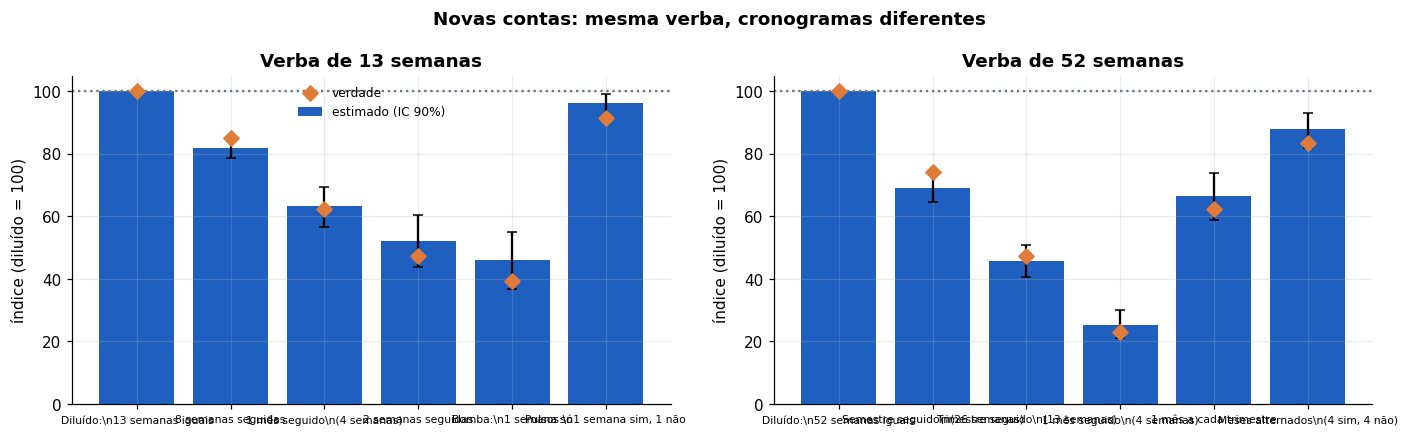

In [41]:
def plot_cronogramas(cron, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, (hor, d) in zip(axes, cron.groupby("horizonte", sort=False)):
        y = d["indice"].values; x = np.arange(len(d))
        ax.bar(x, y, color=AZUL, yerr=[y - d["ic90_baixo"], d["ic90_alto"] - y], capsize=3, label="estimado (IC 90%)")
        ax.scatter(x, d["indice_verdade"], color=LARANJA, marker="D", s=50, zorder=3, label="verdade")
        ax.axhline(100, color=CINZA, ls=":")
        ax.set_xticks(x); ax.set_xticklabels([c.replace(": ", ":\\n").replace(" (", "\\n(") for c in d["cenario"]], fontsize=7)
        ax.set_title(f"Verba de {hor}"); ax.set_ylabel("índice (diluído = 100)")
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(titulo, fontweight="bold"); plt.tight_layout(); plt.show()

plot_cronogramas(cron_contas, "Novas contas: mesma verba, cronogramas diferentes")

**Leitura (novas contas).** Diluir ganha nos dois horizontes e o ranking do modelo bate com o da verdade. No trimestre, a "bomba" de 1 semana rende **~46%** do diluído (IC 90%: 37% a 55%; verdade: 39%) e 1 mês seguido rende ~63%. No ano, concentrar tudo em **1 mês** rende só **~25%** do diluído (21% a 30%; verdade: 23%), enquanto "1 mês a cada trimestre" rende ~67% e meses alternados ~88%. Pulsos curtos (1 semana sim, 1 não) perdem pouco, porque o adstock preenche parte do intervalo. Os dois cronogramas mais concentrados do trimestre têm pico acima de 1,5x o máximo semanal histórico, então são **extrapolação** e a confiança neles é menor.

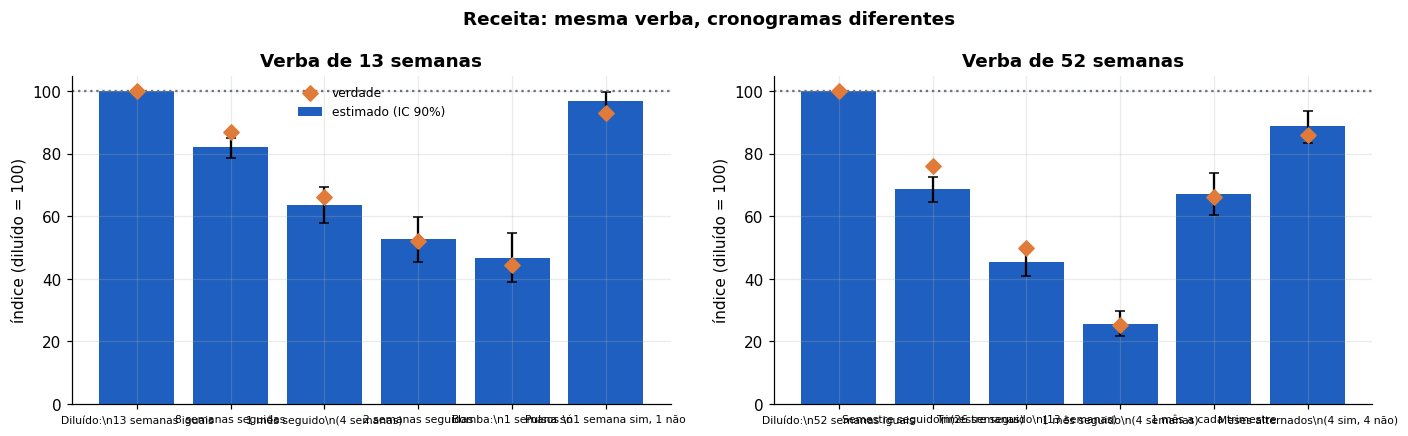

,horizonte,cenario,indice,ic90_baixo,ic90_alto,indice_verdade
0,13 semanas,Diluído: 13 semanas iguais,100.0,100.0,100.0,100.0
1,13 semanas,8 semanas seguidas,82.0,79.0,85.0,87.0
2,13 semanas,1 mês seguido (4 semanas),63.0,58.0,69.0,66.0
3,13 semanas,2 semanas seguidas,53.0,45.0,60.0,52.0
4,13 semanas,Bomba: 1 semana só,47.0,39.0,55.0,44.0
5,13 semanas,"Pulsos: 1 semana sim, 1 não",97.0,93.0,100.0,93.0
6,52 semanas,Diluído: 52 semanas iguais,100.0,100.0,100.0,100.0
7,52 semanas,Semestre seguido (26 semanas),69.0,65.0,73.0,76.0
8,52 semanas,Trimestre seguido (13 semanas),45.0,41.0,50.0,50.0
9,52 semanas,1 mês seguido (4 semanas),25.0,22.0,30.0,25.0


In [42]:
# Mesma análise para a receita
cron_rec = simular_cronogramas(m_rec, False, "receita_mil")
plot_cronogramas(cron_rec, "Receita: mesma verba, cronogramas diferentes")
cron_rec.round(0)

### 8.1 E por campanha?

A ordem dos cronogramas é a mesma em todas as campanhas, mas **o tamanho da perda muda**: quem satura mais rápido perde mais ao concentrar a verba. No app do projeto há a visão por campanha, com intervalos. Em novas contas, por exemplo, uma "bomba" de 1 semana rende ~58% do diluído no Meta, mas só ~34% em Afiliados e ~36% no TikTok.

**Quanto e onde investir.** Para a pergunta "dada uma verba X, como dividir entre as campanhas?", o app tem um alocador que coloca cada real onde o retorno marginal (das curvas de resposta) é maior. Um aviso importante: nas curvas *verdadeiras*, a alocação sugerida ficou **pior** que manter a proporção atual, porque as curvas estimadas superestimam o Meta e o otimizador confia nelas. É o risco de otimizar em cima de uma curva incerta.

## 9. Conclusões e limitações

### O que este projeto mostra

1. **MAPE bom não valida atribuição.** O modelo ingênuo tinha MAPE de ~4% (treino) e ~5,5% (teste), mas errou a contribuição por canal em média **5,1 p.p.**, e o Google Search em mais de 20 p.p. O ajustado chegou a ~3% / ~3,3% de MAPE **e** a 1,9 p.p. de erro médio (Google: 1,8 p.p.).
2. **O que resolveu foram decisões de modelagem, não mais dados:** sazonalidade explícita nos controles, tendência simples (`knots=2`) e uma prior de ROI dentro de uma faixa plausível de negócio.
3. **O KPI muda a decisão.** O YouTube explica ~2% das novas contas mas ~8% da receita (ROI de ~9,5 R$ por R$ 1); TikTok e Afiliados fazem o contrário: são os menores CAC em contas (~R$ 76 e ~R$ 103) e rendem pouco em receita. Um único modelo de "conversões" esconderia isso.
4. **Curvas com sentido:** todos os canais saem com retorno decrescente, e o alerta de saturação (mROI/ROI) aponta o YouTube como o mais saturado em contas.
5. **Diluir vence concentrar.** Com a mesma verba, uma bomba de 1 semana rende ~46% do diluído (trimestre) e tudo em 1 mês rende ~25% (ano), e o ranking do modelo bate com o da verdade.
6. **Dentro do baseline, tendência e desemprego se confundem.** O baseline total é bem estimado, mas a divisão entre "tendência de crescimento" e "efeito do desemprego" não é identificável com esses dados.

### Onde o modelo errou (e por quê)

- **Meta foi superestimado em novas contas** (12,4% estimado contra 6,9% verdadeiro, com o intervalo de 90% de 7,8% a 18,2% *não* contendo a verdade). No dado, o investimento em Meta sobe junto com promoção e Black Friday (plantei essa multicolinearidade de propósito), e o modelo não consegue separar totalmente os dois. **Um intervalo de credibilidade pode estar bem calibrado no modelo e ainda assim errado se a estrutura do dado confunde causas.**
- **Otimizar em cima de curva incerta pode piorar o resultado:** nas curvas verdadeiras, a alocação sugerida rendeu menos que manter a proporção atual (o Meta superestimado atrai verba).
- **O decay do adstock é mal identificado** (ex.: Google estimado em ~0,43 contra 0,20 verdadeiro). Séries de 3 anos semanais não têm informação suficiente para separar bem "efeito curto" de "efeito médio". O ROI e a contribuição saem melhores que o decay.

### Limitações

- Dado sintético é mais limpo que o real: sem quebras de tracking, mudanças de mix ou efeito de concorrentes.
- Modelo nacional (um único "geo"): com regiões, o Meridian ganha poder de identificação.
- Holdout único de 20 semanas. O ideal é backtest com janelas rolantes.
- O alerta de saturação é uma regra prática (limiares deste projeto), não um teste estatístico.

### Próximos passos

- **Calibrar com experimentos de incrementalidade (geo-lift/holdout de canal)**, transformando o resultado do teste em prior de ROI: é o remédio direto para o caso do Meta.
- Otimização de orçamento com o `optimizer` do Meridian usando as curvas estimadas.
- Backtest rolante e análise de sensibilidade às priors.